In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# Load your content type data
df = pd.read_csv('content_type_distribution.csv')  # Ensure this file exists and is in correct format

# Create a custom Netflix gradient colormap
netflix_cmap = LinearSegmentedColormap.from_list("netflix_gradient", ["#e30913", "#141414"])
colors = [netflix_cmap(i / (len(df) - 1)) for i in range(len(df))]

In [3]:
# Custom label function to show both type and percentage
def make_autopct(values):
    def autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        label_index = values.index(val) if val in values else 0
        label = df['type'].iloc[label_index]
        return f"{label}\n{pct:.1f}%"
    return autopct

# Plot pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    df['total'],
    labels=None,  # We'll show them inside the chart instead
    autopct=make_autopct(df['total'].tolist()),
    colors=colors,
    startangle=90,
    textprops={'color': 'white', 'fontsize': 12}
)
plt.title('Content Type Distribution on Netflix', color='white', fontsize=14)
plt.tight_layout()

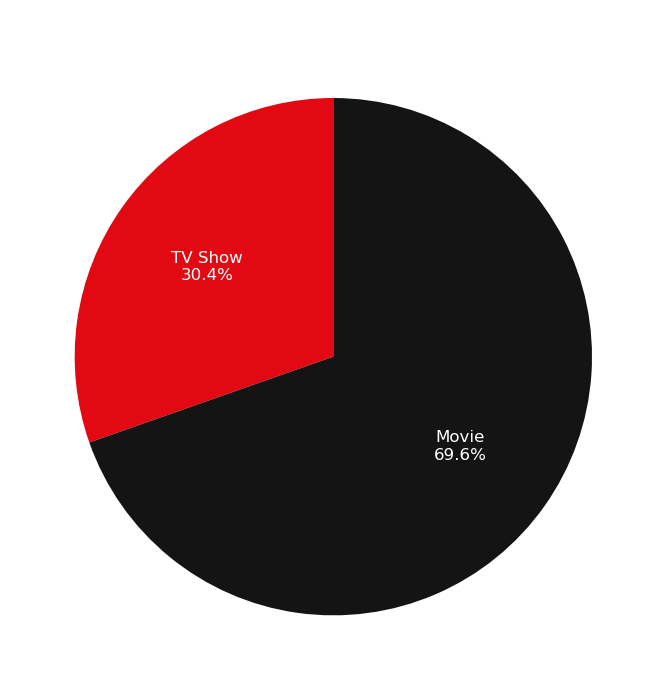

In [4]:
# Save and show
plt.savefig('visualizations/content_type_distribution_pie.png', dpi=300, facecolor='white')
plt.show()